In [1]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.metrics.pairwise import euclidean_distances
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt

In [2]:
df = pd.read_csv('cars.csv', encoding='latin1')

In [3]:
df.head(10)

,Company Names,Cars Names,Engines,CC/Battery Capacity,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Cars Prices,Fuel Types,Seats,Torque
0,FERRARI,SF90 STRADALE,V8,3990 cc,963 hp,340 km/h,2.5 sec,"$1,100,000",plug in hyrbrid,2,800 Nm
1,ROLLS ROYCE,PHANTOM,V12,6749 cc,563 hp,250 km/h,5.3 sec,"$460,000",Petrol,5,900 Nm
2,Ford,KA+,1.2L Petrol,"1,200 cc",70-85 hp,165 km/h,10.5 sec,"$12,000-$15,000",Petrol,5,100 - 140 Nm
3,MERCEDES,GT 63 S,V8,"3,982 cc",630 hp,250 km/h,3.2 sec,"$161,000",Petrol,4,900 Nm
4,AUDI,AUDI R8 Gt,V10,"5,204 cc",602 hp,320 km/h,3.6 sec,"$253,290",Petrol,2,560 Nm
5,BMW,Mclaren 720s,V8,"3,994 cc",710 hp,341 km/h,2.9 sec,"$499,000",Petrol,2,770 Nm
6,ASTON MARTIN,VANTAGE F1,V8,"3,982 cc",656 hp,314 km/h,3.6 sec,"$193,440",Petrol,2,685 Nm
7,BENTLEY,Continental GT Azure,V8,"3,996 cc",550 hp,318 km/h,4.0 sec,"$311,000",Petrol,4,900 Nm
8,LAMBORGHINI,VENENO ROADSTER,V12,"6,498 cc",750 hp,356 km/h,2.9 sec,"$4,500,000",Petrol,2,690 Nm
9,FERRARI,F8 TRIBUTO,V8,"3,900 cc",710 hp,340 km/h,2.9 sec,"$280,000",Petrol,2,770 Nm


Choosing Metrics for Clusters

In [4]:
clustering_metrics = ['HorsePower', 'Total Speed', 'Performance(0 - 100 )KM/H']

In [5]:
profiling_features = ['Company Names', 'Cars Names', 'Engines', 'Cars Prices', 'Fuel Types']

In [6]:
df_subset = df[clustering_metrics + profiling_features].copy()

In [12]:
df_subset.head()

,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Company Names,Cars Names,Engines,Cars Prices,Fuel Types
0,963.0,340.0,2.5,FERRARI,SF90 STRADALE,V8,"$1,100,000",plug in hyrbrid
1,563.0,250.0,5.3,ROLLS ROYCE,PHANTOM,V12,"$460,000",Petrol
2,70.0,165.0,10.5,Ford,KA+,1.2L Petrol,"$12,000-$15,000",Petrol
3,630.0,250.0,3.2,MERCEDES,GT 63 S,V8,"$161,000",Petrol
4,602.0,320.0,3.6,AUDI,AUDI R8 Gt,V10,"$253,290",Petrol


Data Cleaning and Scaling

In [8]:
df_subset['HorsePower'] = df_subset['HorsePower'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [9]:
df_subset['Total Speed'] = df_subset['Total Speed'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [10]:
df_subset['Performance(0 - 100 )KM/H'] = df_subset['Performance(0 - 100 )KM/H'].astype(str).str.extract(r'(\d+\.?\d*)').astype(float)

In [11]:
df_clean = df_subset.dropna(subset=clustering_metrics).copy()

In [13]:
scaler = StandardScaler()
scaled_values = scaler.fit_transform(df_clean[clustering_metrics])

In [14]:
df_scaled = pd.DataFrame(scaled_values, columns=clustering_metrics, index=df_clean.index)

In [15]:
df_final = pd.concat([df_scaled, df_clean[profiling_features]], axis=1)

In [16]:
df_final.head()

,HorsePower,Total Speed,Performance(0 - 100 )KM/H,Company Names,Cars Names,Engines,Cars Prices,Fuel Types
0,3.015819,2.337117,-1.530418,FERRARI,SF90 STRADALE,V8,"$1,100,000",plug in hyrbrid
1,1.193722,0.629632,-0.684151,ROLLS ROYCE,PHANTOM,V12,"$460,000",Petrol
2,-1.052013,-0.982994,0.887488,Ford,KA+,1.2L Petrol,"$12,000-$15,000",Petrol
3,1.498923,0.629632,-1.318851,MERCEDES,GT 63 S,V8,"$161,000",Petrol
4,1.371376,1.957676,-1.197956,AUDI,AUDI R8 Gt,V10,"$253,290",Petrol


Similarity Measurement

In [17]:
distance_matrix = euclidean_distances(df_scaled)

In [18]:
euclidean_similarity = 1 / (1 + distance_matrix)

In [21]:
car_index = 4 
car_name = df_final.iloc[car_index]['Company Names']

In [22]:
similar_scores = list(enumerate(euclidean_similarity[car_index]))
similar_scores = sorted(similar_scores, key=lambda x: x[1], reverse=True)

In [29]:
print(f"\n--- Top 10 Cars Most Similar to: {car_name} ---")
for i in range(1, 11):
    match_index = similar_scores[i][0]
    match_score = similar_scores[i][1]
    match_company = df_final.iloc[match_index]['Company Names']
    match_model = df_final.iloc[match_index]['Cars Names']

    print(f"{match_company}: {match_model}: {match_score * 100:.1f}%")


--- Top 10 Cars Most Similar to: AUDI ---
FERRARI: ROMA: 93.0%
FERRARI: ROMA SPIDER: 93.0%
ASTON MARTIN: DB11: 91.0%
LAMBORGHINI: HURACAN SPYDER: 89.4%
ASTON MARTIN: VANQUISH: 88.8%
Jaguar Land Rover: Jaguar F-Type SVR: 88.8%
FERRARI: PORTOFINO: 88.6%
FERRARI: PORTOFINO M: 88.6%
LAMBORGHINI: HURACAN EVO RWD: 88.0%
LAMBORGHINI: HURACAN EVO RWD SPYDER: 88.0%


KMeans and Elbow Curve

In [30]:
inertia_values = []
K_range = range(1, 11)

In [ ]:
for k in K_range:
    kmeans_test = KMeans(n_clusters=k, random_state=42, n_init=10)
    kmeans_test.fit(df_scaled)
    
    inertia_values.append(kmeans_test.inertia_)

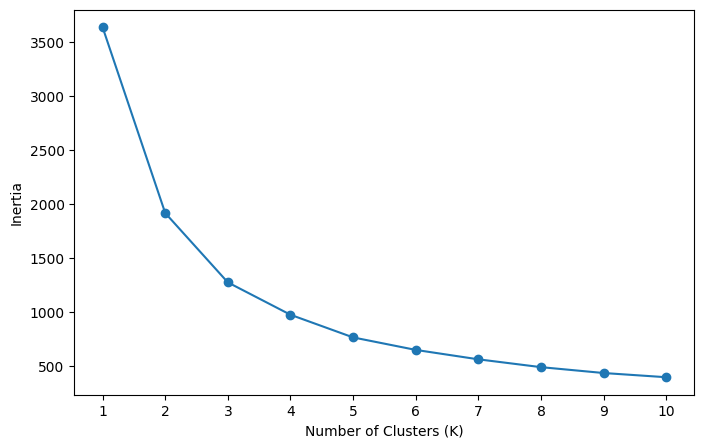

In [32]:
# Plot the Elbow Curve
plt.figure(figsize=(8, 5))
plt.plot(K_range, inertia_values, marker='o')
plt.xlabel('Number of Clusters (K)')
plt.ylabel('Inertia')
plt.xticks(K_range)
plt.show()

In [33]:
final_kmeans = KMeans(n_clusters=3, random_state=42, n_init=10)
df_final['Cluster'] = final_kmeans.fit_predict(df_scaled)

In [41]:
df_final = df_final.reset_index(drop=True)

Create Nodes and Edges

In [42]:
import networkx as nx
G = nx.Graph()

In [43]:
for i, row in df_final.iterrows():
    G.add_node(i,
               car_name=str(row['Cars Names']),
               cluster=int(row['Cluster']))

In [44]:
THRESHOLD = 0.8
num_cars = len(df_final)

In [45]:
for i in range(num_cars):
    for j in range(i + 1, num_cars):
        sim_score = euclidean_similarity[i][j]
        if sim_score >= THRESHOLD:
            G.add_edge(i, j, weight=float(sim_score))

In [46]:
print(f'Nodes: {G.number_of_nodes()}')
print(f'Edges: {G.number_of_edges()}')

Nodes: 1212
Edges: 15120


In [47]:
export_filename = "car_clusters.gexf"
nx.write_gexf(G, export_filename)